In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

uploaded = files.upload()

df = pd.read_csv("Day13_Restaurant_Branch_Performance_Dataset.csv")


Saving Day13_Restaurant_Branch_Performance_Dataset.csv to Day13_Restaurant_Branch_Performance_Dataset (1).csv


In [5]:
print(df.shape)

(350, 22)


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Record_ID         350 non-null    object 
 1   Date              350 non-null    object 
 2   Day               350 non-null    object 
 3   Month             350 non-null    object 
 4   Branch            350 non-null    object 
 5   Region            350 non-null    object 
 6   Store_Type        350 non-null    object 
 7   Staff_Count       350 non-null    int64  
 8   Marketing_Spend   350 non-null    float64
 9   Customers         350 non-null    int64  
 10  Orders            350 non-null    int64  
 11  Average_Bill      350 non-null    float64
 12  Revenue           350 non-null    float64
 13  Food_Cost         350 non-null    float64
 14  Operating_Cost    350 non-null    float64
 15  Profit            350 non-null    float64
 16  Avg_Delivery_Min  350 non-null    float64
 1

In [7]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Record_ID,350,350,ST0350,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,350,161,2026-05-21,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day,350,7,Tuesday,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,350,6,February,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Branch,350,8,Srinagar,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,350,3,South,137,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Type,350,3,Standard,196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Staff_Count,350.0,NaN,NaN,NaN,11.957143,4.338261,5.0,9.0,11.0,15.0,24.0
Marketing_Spend,350.0,NaN,NaN,NaN,5516.347743,2050.906967,725.35,4339.7275,5393.37,6748.5025,11784.96
Customers,350.0,NaN,NaN,NaN,217.377143,56.722524,77.0,180.25,213.0,255.75,360.0


In [8]:
print(df.isnull().sum())

Record_ID             0
Date                  0
Day                   0
Month                 0
Branch                0
Region                0
Store_Type            0
Staff_Count           0
Marketing_Spend       0
Customers             0
Orders                0
Average_Bill          0
Revenue               0
Food_Cost             0
Operating_Cost        0
Profit                0
Avg_Delivery_Min      0
Customer_Rating       0
Temperature_C         0
Humidity_Percent      0
Weather               0
Promotion           184
dtype: int64


In [9]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

In [11]:
for col in categorical_cols:
    display(df[col].value_counts(dropna=False))

,count
Record_ID,
ST0350,1
ST0001,1
ST0002,1
ST0003,1
ST0004,1
...,...
ST0019,1
ST0018,1
ST0017,1


,count
Date,
2026-05-21,5
2026-02-28,5
2026-01-14,4
2026-05-03,4
2026-03-10,4
...,...
2026-03-30,1
2026-02-22,1
2026-05-10,1


,count
Day,
Tuesday,56
Saturday,55
Monday,54
Wednesday,50
Friday,47
Sunday,47
Thursday,41


,count
Month,
February,65
January,62
June,61
March,58
April,56
May,48


,count
Branch,
Srinagar,52
Jaipur,48
Kochi,48
Bengaluru,46
Mumbai,44
Hyderabad,43
Pune,37
Delhi,32


,count
Region,
South,137
North,132
West,81


,count
Store_Type,
Standard,196
Express,102
Premium,52


,count
Weather,
Clear,189
Cloudy,82
Rain,48
Hot,31


,count
Promotion,
NaN,184
Weekend Offer,74
Combo Deal,59
Loyalty Offer,33


In [13]:
display(df[numeric_cols].skew().sort_values(ascending=False).to_frame("Skewness"))
display(df[numeric_cols].corr().round(3))

,Skewness
Food_Cost,0.925143
Operating_Cost,0.908717
Revenue,0.862027
Profit,0.809795
Staff_Count,0.526095
Average_Bill,0.309140
Orders,0.270349
Customers,0.234826
Avg_Delivery_Min,0.135023
Marketing_Spend,0.103991


,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
Staff_Count,1.000,0.283,0.689,0.672,0.522,0.695,0.680,0.788,0.559,-0.182,0.084,0.083,-0.018
Marketing_Spend,0.283,1.000,0.405,0.416,0.332,0.431,0.405,0.485,0.350,0.101,-0.062,0.058,-0.046
Customers,0.689,0.405,1.000,0.980,0.532,0.876,0.844,0.856,0.836,0.184,-0.048,0.002,-0.101
Orders,0.672,0.416,0.980,1.000,0.522,0.858,0.828,0.841,0.815,0.187,-0.051,0.020,-0.094
Average_Bill,0.522,0.332,0.532,0.522,1.000,0.843,0.836,0.798,0.828,-0.033,0.042,-0.049,-0.044
Revenue,0.695,0.431,0.876,0.858,0.843,1.000,0.979,0.963,0.967,0.079,0.008,-0.026,-0.091
Food_Cost,0.680,0.405,0.844,0.828,0.836,0.979,1.000,0.973,0.918,0.077,0.003,-0.028,-0.080
Operating_Cost,0.788,0.485,0.856,0.841,0.798,0.963,0.973,1.000,0.862,0.020,0.021,0.014,-0.068
Profit,0.559,0.350,0.836,0.815,0.828,0.967,0.918,0.862,1.000,0.129,-0.005,-0.063,-0.107
Avg_Delivery_Min,-0.182,0.101,0.184,0.187,-0.033,0.079,0.077,0.020,0.129,1.000,-0.437,0.005,-0.112


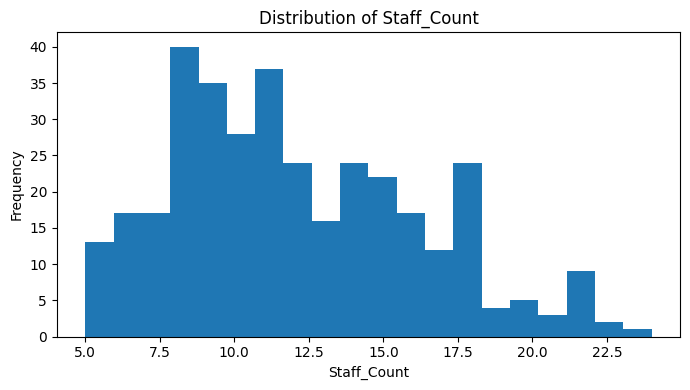

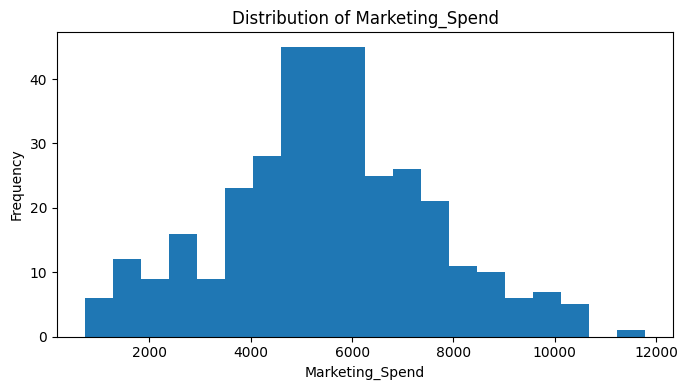

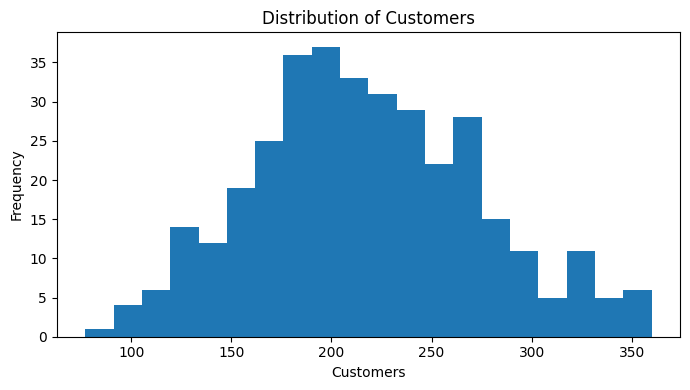

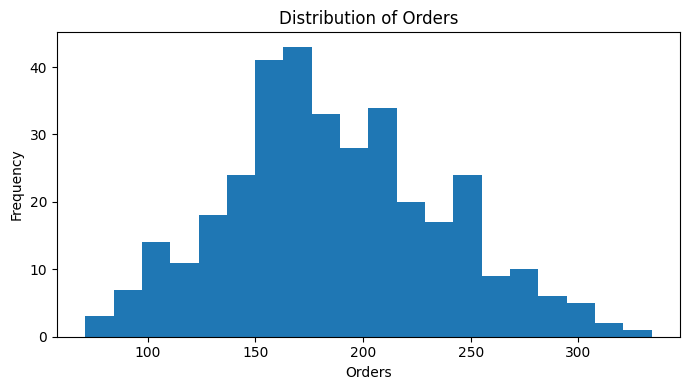

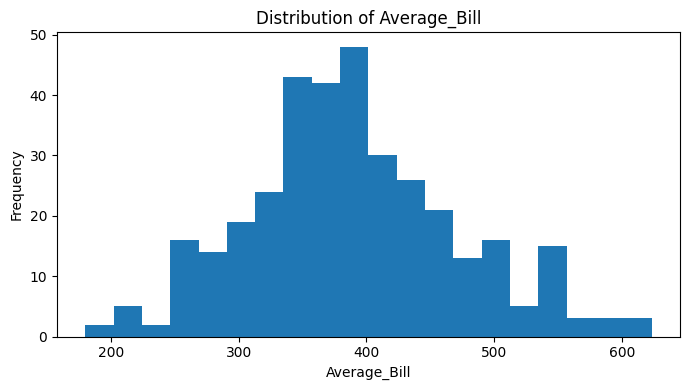

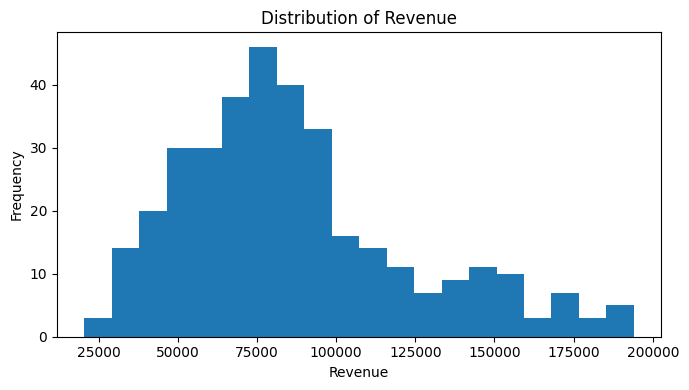

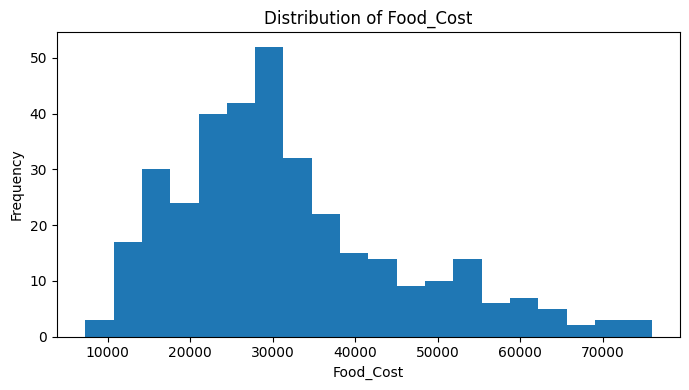

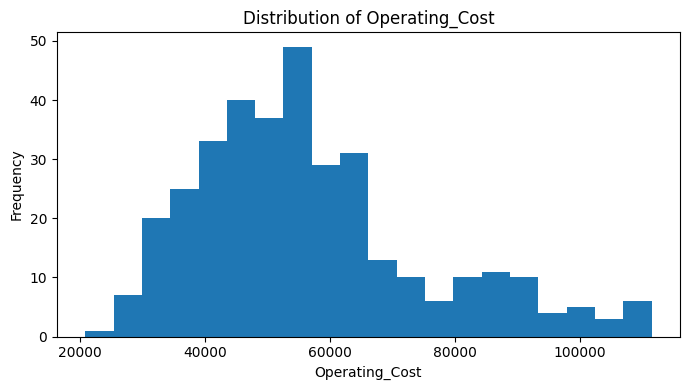

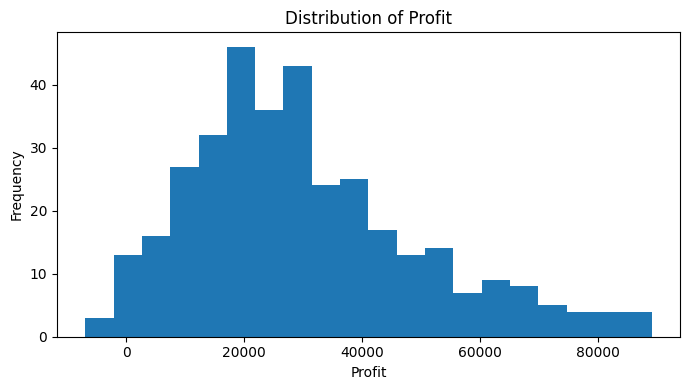

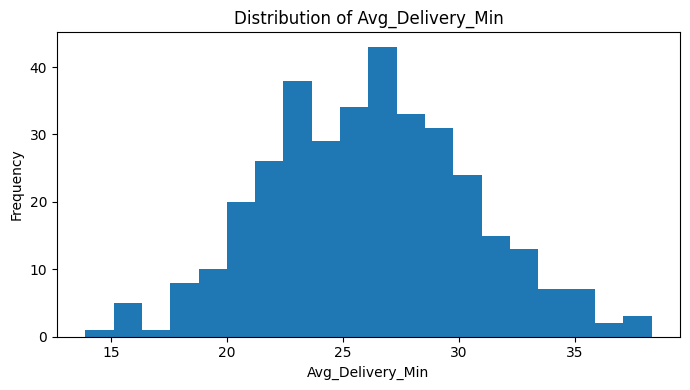

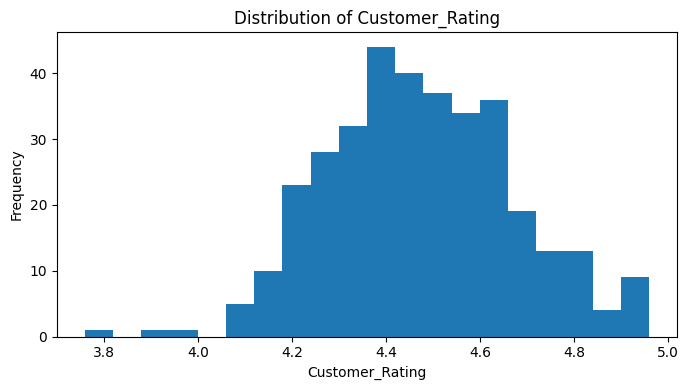

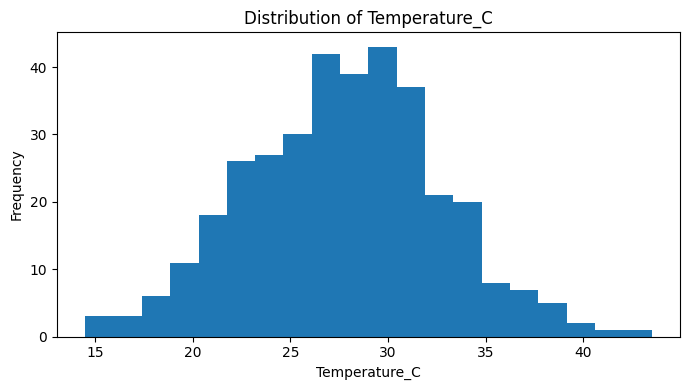

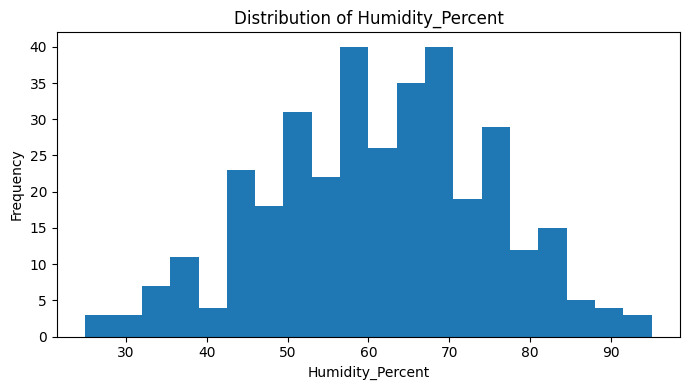

In [14]:
for col in numeric_cols:
    plt.figure(figsize=(7,4))
    plt.hist(df[col].dropna(), bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [15]:
for col in categorical_cols:
    if df[col].nunique(dropna=True) <= 20:
        display(df.groupby(col)[numeric_cols].mean(numeric_only=True).round(2))

,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
Day,,,,,,,,,,,,,
Friday,11.40,5124.16,200.72,172.79,386.41,80418.65,29129.91,53385.55,27033.10,25.18,4.50,26.98,60.92
Monday,10.96,5531.42,202.24,171.81,380.70,79398.29,29441.28,52981.57,26416.72,26.07,4.49,28.39,63.64
Saturday,12.58,5497.02,251.75,218.35,390.96,99643.14,36463.37,61947.86,37695.28,27.24,4.47,26.88,61.55
Sunday,13.34,5724.79,256.66,219.83,390.64,101835.93,36838.32,63137.72,38698.20,27.70,4.43,27.70,59.28
Thursday,11.05,5304.25,206.85,176.61,378.11,81236.42,29717.78,53567.45,27668.98,26.44,4.45,27.97,60.76
Tuesday,12.98,5704.14,202.50,174.96,400.23,83801.58,30623.08,56842.63,26958.94,24.06,4.48,27.94,62.86
Wednesday,11.16,5657.64,199.94,173.80,392.39,80674.05,30069.96,53866.43,26807.62,26.23,4.44,28.32,59.62


,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
Month,,,,,,,,,,,,,
April,12.16,5283.48,219.12,185.89,393.21,88531.11,33334.32,58430.67,30100.44,25.62,4.45,27.28,62.28
February,12.18,5516.64,218.02,187.92,390.82,87147.27,31889.46,56890.48,30256.80,26.79,4.44,28.27,63.06
January,11.48,5729.15,213.82,186.21,387.83,84384.44,30955.32,55371.81,29012.63,26.30,4.48,27.90,60.60
June,11.38,5472.18,207.90,177.64,366.18,78780.56,28758.05,52893.01,25887.55,26.13,4.47,27.51,61.70
March,11.81,5368.66,216.19,186.16,391.44,86936.61,31050.72,55386.53,31550.08,25.72,4.50,27.99,58.84
May,12.94,5747.34,232.54,201.38,408.51,97688.38,35806.07,61990.88,35697.50,25.87,4.46,27.35,61.31


,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
Branch,,,,,,,,,,,,,
Bengaluru,12.85,5413.93,227.50,195.11,385.73,90732.12,33193.52,58841.20,31890.91,26.56,4.47,28.26,60.85
Delhi,11.56,5762.63,213.97,184.22,394.62,87573.87,31650.34,56188.57,31385.30,25.69,4.49,27.94,60.40
Hyderabad,12.28,5455.15,220.79,189.12,387.92,88804.90,32617.02,57401.92,31402.98,25.52,4.47,27.71,63.32
Jaipur,11.71,5356.64,223.27,193.56,385.31,86746.16,31960.53,56276.45,30469.70,26.58,4.47,26.92,58.73
Kochi,11.83,5660.43,209.06,181.46,399.72,85574.62,31791.25,56672.58,28902.04,25.84,4.42,27.65,61.00
Mumbai,10.89,5580.10,213.77,181.50,371.32,80779.25,29952.57,54198.26,26580.99,26.86,4.44,27.73,61.18
Pune,11.86,5590.57,214.92,187.97,394.34,88107.49,31924.39,56841.92,31265.57,25.53,4.54,28.48,61.82
Srinagar,12.46,5413.67,214.73,183.17,393.38,86746.47,31369.14,56443.56,30302.92,25.97,4.48,27.51,63.14


,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
Region,,,,,,,,,,,,,
North,11.97,5477.53,217.65,187.20,390.75,86946.94,31652.36,56320.98,30625.96,26.13,4.48,27.40,60.87
South,12.31,5513.23,218.93,188.45,391.32,88320.22,32521.27,57629.65,30690.57,25.98,4.45,27.87,61.68
West,11.33,5584.88,214.30,184.46,381.83,84126.72,30853.28,55405.86,28720.86,26.25,4.49,28.07,61.47


,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
Store_Type,,,,,,,,,,,,,
Express,7.96,5122.66,161.29,137.94,325.48,52327.16,19245.34,39585.03,12742.14,26.17,4.46,27.54,63.08
Premium,17.60,8065.56,298.73,258.10,514.67,152867.31,56372.74,89977.08,62890.24,26.40,4.46,27.99,58.79
Standard,12.54,5044.90,224.98,193.77,388.55,87268.67,31827.72,56637.88,30630.79,25.98,4.47,27.78,61.08


,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
Weather,,,,,,,,,,,,,
Clear,11.91,5475.13,216.24,186.44,382.41,84720.81,31304.35,56002.08,28718.73,25.89,4.47,27.91,61.14
Cloudy,11.99,5571.04,216.10,184.76,390.29,87724.00,31639.02,56664.73,31059.27,26.24,4.49,28.35,62.28
Hot,11.16,5427.12,213.03,183.10,408.16,87830.13,32568.63,56070.40,31759.74,27.23,4.44,27.41,63.65
Rain,12.60,5642.85,226.85,195.96,399.68,92974.88,33585.23,59342.12,33632.76,25.95,4.46,26.23,58.92


,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
Promotion,,,,,,,,,,,,,
Combo Deal,11.97,5467.60,218.64,186.86,383.80,86269.73,31940.27,56489.80,29779.94,25.73,4.45,28.21,59.55
Loyalty Offer,12.00,5746.03,226.97,195.09,394.33,91937.89,33947.10,59591.80,32346.09,26.35,4.44,28.22,64.60
Weekend Offer,11.16,5592.81,224.54,194.51,383.67,88808.72,32744.60,57078.09,31730.63,26.96,4.45,27.84,60.84


In [16]:
for col in ["Branch", "Region", "Store Type"]:
    if col in df.columns:
        display(df.groupby(col)[numeric_cols].mean(numeric_only=True).round(2))

,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
Branch,,,,,,,,,,,,,
Bengaluru,12.85,5413.93,227.50,195.11,385.73,90732.12,33193.52,58841.20,31890.91,26.56,4.47,28.26,60.85
Delhi,11.56,5762.63,213.97,184.22,394.62,87573.87,31650.34,56188.57,31385.30,25.69,4.49,27.94,60.40
Hyderabad,12.28,5455.15,220.79,189.12,387.92,88804.90,32617.02,57401.92,31402.98,25.52,4.47,27.71,63.32
Jaipur,11.71,5356.64,223.27,193.56,385.31,86746.16,31960.53,56276.45,30469.70,26.58,4.47,26.92,58.73
Kochi,11.83,5660.43,209.06,181.46,399.72,85574.62,31791.25,56672.58,28902.04,25.84,4.42,27.65,61.00
Mumbai,10.89,5580.10,213.77,181.50,371.32,80779.25,29952.57,54198.26,26580.99,26.86,4.44,27.73,61.18
Pune,11.86,5590.57,214.92,187.97,394.34,88107.49,31924.39,56841.92,31265.57,25.53,4.54,28.48,61.82
Srinagar,12.46,5413.67,214.73,183.17,393.38,86746.47,31369.14,56443.56,30302.92,25.97,4.48,27.51,63.14


,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
Region,,,,,,,,,,,,,
North,11.97,5477.53,217.65,187.20,390.75,86946.94,31652.36,56320.98,30625.96,26.13,4.48,27.40,60.87
South,12.31,5513.23,218.93,188.45,391.32,88320.22,32521.27,57629.65,30690.57,25.98,4.45,27.87,61.68
West,11.33,5584.88,214.30,184.46,381.83,84126.72,30853.28,55405.86,28720.86,26.25,4.49,28.07,61.47
